In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split

In [5]:
datos = sns.load_dataset('penguins')
print(datos)
datos.describe()

    species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0    Adelie  Torgersen            39.1           18.7              181.0   
1    Adelie  Torgersen            39.5           17.4              186.0   
2    Adelie  Torgersen            40.3           18.0              195.0   
3    Adelie  Torgersen             NaN            NaN                NaN   
4    Adelie  Torgersen            36.7           19.3              193.0   
..      ...        ...             ...            ...                ...   
339  Gentoo     Biscoe             NaN            NaN                NaN   
340  Gentoo     Biscoe            46.8           14.3              215.0   
341  Gentoo     Biscoe            50.4           15.7              222.0   
342  Gentoo     Biscoe            45.2           14.8              212.0   
343  Gentoo     Biscoe            49.9           16.1              213.0   

     body_mass_g     sex  
0         3750.0    Male  
1         3800.0  Female  
2     

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [6]:
train, test = train_test_split(datos, test_size = 0.4, stratify=datos['species'], random_state = 26)
train

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
226,Gentoo,Biscoe,45.4,14.6,211.0,4800.0,Female
203,Chinstrap,Dream,51.4,19.0,201.0,3950.0,Male
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
270,Gentoo,Biscoe,46.6,14.2,210.0,4850.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
90,Adelie,Dream,35.7,18.0,202.0,3550.0,Female
131,Adelie,Torgersen,43.1,19.2,197.0,3500.0,Male
323,Gentoo,Biscoe,49.1,15.0,228.0,5500.0,Male
95,Adelie,Dream,40.8,18.9,208.0,4300.0,Male


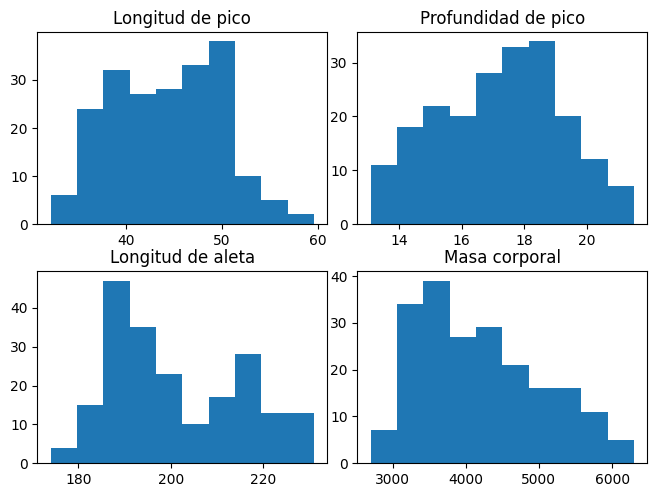

In [39]:
n_bins = 10
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2)
ax1.hist(train['bill_length_mm'], bins = n_bins)
ax1.set_title('Longitud de pico')
ax2.hist(train['bill_depth_mm'], bins = n_bins)
ax2.set_title('Profundidad de pico')
ax3.hist(train['flipper_length_mm'], bins = n_bins)
ax3.set_title('Longitud de aleta')
ax4.hist(train['body_mass_g'], bins = n_bins)
ax4.set_title('Masa corporal')
fig.tight_layout(pad = 0.1)
plt.show()

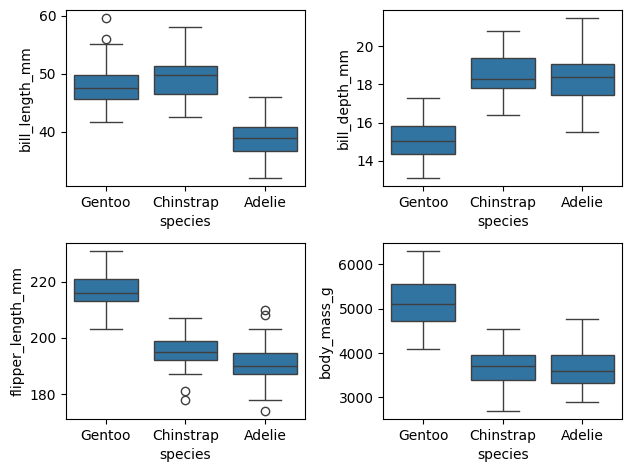

In [18]:
fig1, axs1 = plt.subplots(nrows=2, ncols=2)
rn = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
cn = ['Gentoo', 'Chinstrap', 'Adelie']
sns.boxplot(x='species', y = rn[0], data=train, order= cn, ax = axs1[0,0])
sns.boxplot(x='species', y = rn[1], data=train, order= cn, ax = axs1[0,1])
sns.boxplot(x='species', y = rn[2], data=train, order= cn, ax = axs1[1,0])
sns.boxplot(x='species', y = rn[3], data=train, order= cn, ax = axs1[1,1])
fig1.tight_layout(pad=1.0)
plt.show()


<Axes: xlabel='species', ylabel='bill_depth_mm'>

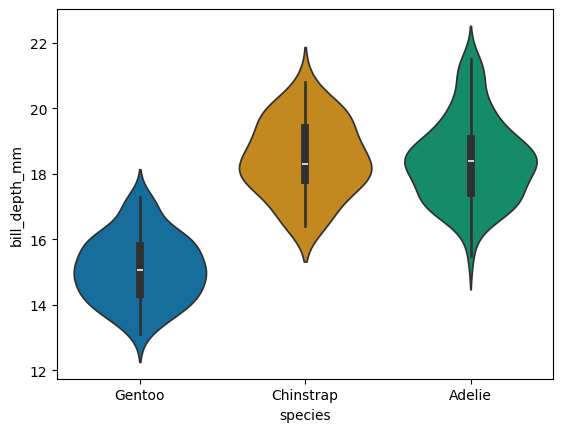

In [21]:
sns.violinplot(x='species', y='bill_depth_mm', data = train, hue='species', order = cn, palette ='colorblind')

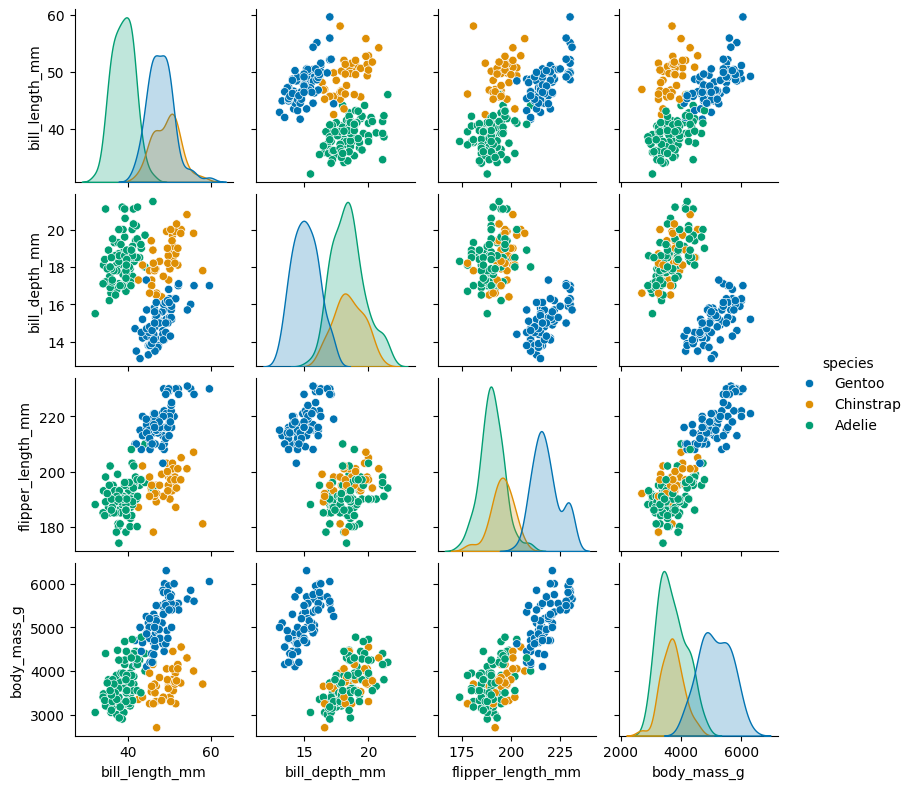

In [7]:
sns.pairplot(data=train, hue='species', height = 2, palette = 'colorblind')

In [24]:
corrmat = train.corr(numeric_only = True)
corrmat

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.240412,0.631129,0.576282
bill_depth_mm,-0.240412,1.000000,-0.608385,-0.478064
flipper_length_mm,0.631129,-0.608385,1.000000,0.872393
body_mass_g,0.576282,-0.478064,0.872393,1.000000


<Axes: >

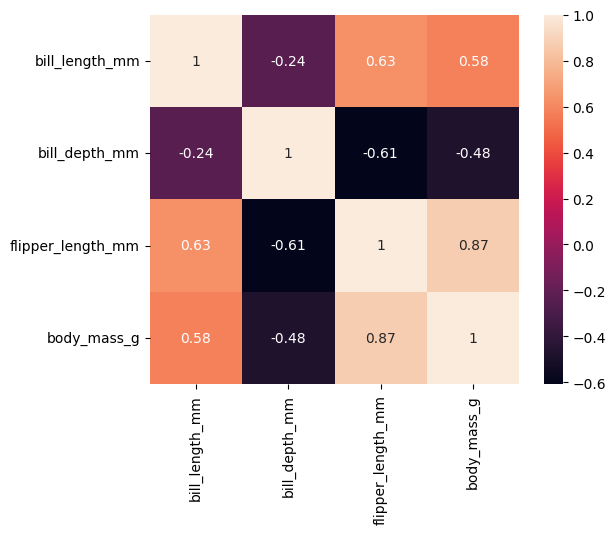

In [25]:
sns.color_palette('mako', as_cmap = True)
sns.heatmap(corrmat, annot=True, square=True)

<Axes: >

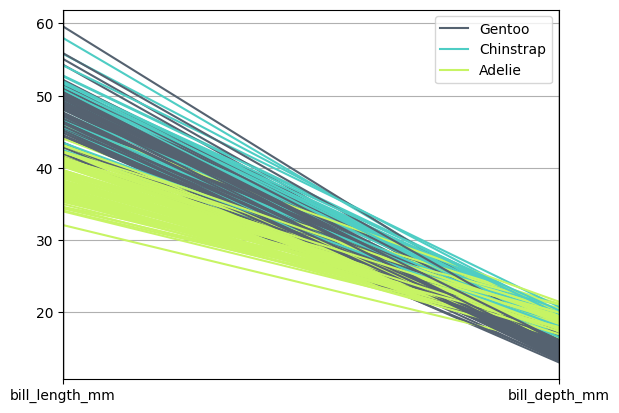

In [37]:
from pandas.plotting import parallel_coordinates
parallel_coordinates(train, 'species', cols=['bill_length_mm', 'bill_depth_mm'], color=("#556270", "#4ECDC4", "#C7F464"))